# Combined EDA notes

This notebook contains my EDA for the six processed datasets.
I used files from `data/processed` and exported tables/plots to the `results` folders.

Datasets: iea, sales, population, charging, stock, survey.

Export paths:
- `results/tables/multi_dataset_eda/<dataset>/`
- `results/figures/multi_dataset_eda/<dataset>/`

Old `consumer` outputs are kept as archive.

In [27]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

In [28]:
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

processed_dir = project_root / 'data' / 'processed'
results_tables_root = project_root / 'results' / 'tables' / 'multi_dataset_eda'
results_figures_root = project_root / 'results' / 'figures' / 'multi_dataset_eda'

DATASETS = {
    'iea': processed_dir / 'iea_ev_clean.csv',
    'sales': processed_dir / 'ev_sales_clean.csv',
    'population': processed_dir / 'ev_population_clean.csv',
    'charging': processed_dir / 'charging_infrastructure_clean.csv',
    'stock': processed_dir / 'stock_market_clean.csv',
    'survey': processed_dir / 'survey_clean.csv',
}

for name in DATASETS:
    (results_tables_root / name).mkdir(parents=True, exist_ok=True)
    (results_figures_root / name).mkdir(parents=True, exist_ok=True)

missing_files = [str(p) for p in DATASETS.values() if not p.exists()]
if missing_files:
    raise FileNotFoundError(f'Missing processed files: {missing_files}')

DATASETS

{'iea': PosixPath('/home/ravindran/workspace/college/6th_Sem/Business Analytics/project/eVehicle-adoption-analytics/data/processed/iea_ev_clean.csv'),
 'sales': PosixPath('/home/ravindran/workspace/college/6th_Sem/Business Analytics/project/eVehicle-adoption-analytics/data/processed/ev_sales_clean.csv'),
 'population': PosixPath('/home/ravindran/workspace/college/6th_Sem/Business Analytics/project/eVehicle-adoption-analytics/data/processed/ev_population_clean.csv'),
 'charging': PosixPath('/home/ravindran/workspace/college/6th_Sem/Business Analytics/project/eVehicle-adoption-analytics/data/processed/charging_infrastructure_clean.csv'),
 'stock': PosixPath('/home/ravindran/workspace/college/6th_Sem/Business Analytics/project/eVehicle-adoption-analytics/data/processed/stock_market_clean.csv'),
 'survey': PosixPath('/home/ravindran/workspace/college/6th_Sem/Business Analytics/project/eVehicle-adoption-analytics/data/processed/survey_clean.csv')}

In [29]:
# Keep output folders clean: remove stale PNGs created in previous runs for these 6 datasets.
managed_datasets = ['iea', 'sales', 'population', 'charging', 'stock', 'survey']
allowed_per_dataset = {
    'correlation_heatmap.png',
    'numeric_distributions.png',
    'missing_values_top20.png',
    'yearly_trend.png',
}
allowed_root_files = {
    'cross_dataset_normalized_yearly_trends.png',
    'stock_ev_scatter.png',
}

removed = []
for ds in managed_datasets:
    folder = results_figures_root / ds
    if not folder.exists():
        continue
    for p in folder.glob('*.png'):
        if p.name not in allowed_per_dataset:
            p.unlink(missing_ok=True)
            removed.append(str(p))

for p in results_figures_root.glob('*.png'):
    if p.name not in allowed_root_files:
        p.unlink(missing_ok=True)
        removed.append(str(p))

print(f'Cleanup done. Removed {len(removed)} stale image(s).')

Cleanup done. Removed 4 stale image(s).


## Data loading

In [30]:
def load_datasets(dataset_map):
    loaded = {}
    for name, path in dataset_map.items():
        df = pd.read_csv(path)
        df.columns = [c.strip() for c in df.columns]
        loaded[name] = df
    return loaded

dfs = load_datasets(DATASETS)
{k: v.shape for k, v in dfs.items()}

{'iea': (2975, 5),
 'sales': (16436, 3),
 'population': (714, 5),
 'charging': (38219, 4),
 'stock': (3356, 9),
 'survey': (325, 41)}

## Dataset profiles and summary tables

In [31]:
def profile_dataset(df, dataset_name, table_root):
    out_dir = table_root / dataset_name
    out_dir.mkdir(parents=True, exist_ok=True)

    profile = pd.DataFrame({
        'dataset': [dataset_name],
        'rows': [len(df)],
        'columns': [df.shape[1]],
        'duplicate_rows': [int(df.duplicated().sum())],
        'missing_cells': [int(df.isna().sum().sum())],
    })
    profile.to_csv(out_dir / 'profile.csv', index=False)

    col_overview = pd.DataFrame({
        'column': df.columns,
        'dtype': [str(df[c].dtype) for c in df.columns],
        'non_null': [int(df[c].notna().sum()) for c in df.columns],
        'null_count': [int(df[c].isna().sum()) for c in df.columns],
        'null_pct': [float(df[c].isna().mean() * 100) for c in df.columns],
        'n_unique': [int(df[c].nunique(dropna=True)) for c in df.columns],
    })
    col_overview.to_csv(out_dir / 'column_overview.csv', index=False)

    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    if num_cols:
        num_summary = df[num_cols].describe().T.reset_index().rename(columns={'index': 'column'})
        num_summary.to_csv(out_dir / 'numeric_summary.csv', index=False)

        corr = df[num_cols].corr(numeric_only=True)
        corr.to_csv(out_dir / 'correlation_matrix.csv')

        out_rows = []
        for c in num_cols:
            s = df[c].dropna()
            if s.empty:
                continue
            q1, q3 = s.quantile(0.25), s.quantile(0.75)
            iqr = q3 - q1
            if iqr == 0:
                out_count = 0
            else:
                low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
                out_count = int(((s < low) | (s > high)).sum())
            out_rows.append({'column': c, 'q1': q1, 'q3': q3, 'iqr': iqr, 'outlier_count': out_count})
        pd.DataFrame(out_rows).to_csv(out_dir / 'outlier_summary_iqr.csv', index=False)

    cat_cols = [c for c in df.columns if c not in num_cols]
    if cat_cols:
        cat_rows = []
        for c in cat_cols:
            s = df[c]
            vc = s.value_counts(dropna=False)
            cat_rows.append({
                'column': c,
                'n_unique': int(s.nunique(dropna=True)),
                'mode': vc.index[0] if len(vc) else np.nan,
                'mode_count': int(vc.iloc[0]) if len(vc) else 0,
            })
            top10 = s.fillna('<NA>').astype(str).value_counts().head(10).reset_index()
            top10.columns = ['value', 'count']
            safe_col = c.lower().replace(' ', '_').replace('/', '_').replace('-', '_')
            top10.to_csv(out_dir / f'top10_{safe_col}.csv', index=False)

        pd.DataFrame(cat_rows).to_csv(out_dir / 'categorical_summary.csv', index=False)

    return profile

profiles = [profile_dataset(df, name, results_tables_root) for name, df in dfs.items()]
master_profile_df = pd.concat(profiles, ignore_index=True)
master_profile_df.to_csv(results_tables_root / 'master_dataset_profile.csv', index=False)
master_profile_df

,dataset,rows,columns,duplicate_rows,missing_cells
0,iea,2975,5,261,0
1,sales,16436,3,2037,0
2,population,714,5,0,0
3,charging,38219,4,158,0
4,stock,3356,9,0,0
5,survey,325,41,3,1803


## Core plots

In [32]:
def plot_missing_top20(df, dataset_name, fig_root):
    miss = (df.isna().mean() * 100).sort_values(ascending=False).head(20)
    if miss.sum() == 0:
        return
    plt.figure(figsize=(10, 6))
    sns.barplot(x=miss.values, y=miss.index, hue=miss.index, legend=False, palette='Reds_r')
    plt.title(f'{dataset_name.upper()} - Top Missing Columns (%)')
    plt.xlabel('Missing %')
    plt.ylabel('Column')
    plt.tight_layout()
    plt.savefig(fig_root / dataset_name / 'missing_values_top20.png', dpi=200)
    plt.close()

def plot_numeric_distributions(df, dataset_name, fig_root, max_cols=8):
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    if not num_cols:
        return
    cols = num_cols[:max_cols]
    n = len(cols)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, c in enumerate(cols):
        sns.histplot(df[c].dropna(), kde=True, ax=axes[i], color='steelblue')
        axes[i].set_title(c)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{dataset_name.upper()} - Numeric Distributions', y=1.01)
    plt.tight_layout()
    plt.savefig(fig_root / dataset_name / 'numeric_distributions.png', dpi=200, bbox_inches='tight')
    plt.close()

def plot_correlation_heatmap(df, dataset_name, fig_root):
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    if len(num_cols) < 2:
        return
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
    plt.title(f'{dataset_name.upper()} - Correlation Heatmap')
    plt.tight_layout()
    plt.savefig(fig_root / dataset_name / 'correlation_heatmap.png', dpi=220)
    plt.close()

for name, df in dfs.items():
    plot_missing_top20(df, name, results_figures_root)
    plot_numeric_distributions(df, name, results_figures_root)
    plot_correlation_heatmap(df, name, results_figures_root)

print('Core figures exported.')

Core figures exported.


## Time trends and EV-stock check

In [33]:
def detect_time_col(df):
    candidates = ['year', 'model year', 'date', 'Date']
    lower_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def detect_primary_value_col(df):
    preferred = ['value', 'ev_sales', 'vehicle_count', 'charging_points', 'Close', 'ev_adoption_score', 'ev_readiness_score']
    for p in preferred:
        if p in df.columns and pd.api.types.is_numeric_dtype(df[p]):
            return p
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    return num_cols[0] if num_cols else None

yearly_series = []

for name, df in dfs.items():
    time_col = detect_time_col(df)
    value_col = detect_primary_value_col(df)
    if time_col is None or value_col is None:
        continue

    temp = df.copy()
    if 'date' in time_col.lower():
        temp['year'] = pd.to_datetime(temp[time_col], errors='coerce', utc=True).dt.year
    else:
        temp['year'] = pd.to_numeric(temp[time_col], errors='coerce')

    trend = temp.dropna(subset=['year', value_col]).groupby('year', as_index=False)[value_col].sum().sort_values('year')
    if trend.empty:
        continue

    trend['yoy_pct'] = trend[value_col].pct_change() * 100
    trend.to_csv(results_tables_root / name / 'yearly_trend.csv', index=False)

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=trend, x='year', y=value_col, marker='o')
    plt.title(f'{name.upper()} - Yearly Trend ({value_col})')
    plt.tight_layout()
    plt.savefig(results_figures_root / name / 'yearly_trend.png', dpi=220)
    plt.close()

    if trend[value_col].nunique() > 1:
        vmin, vmax = trend[value_col].min(), trend[value_col].max()
        trend['normalized_value'] = (trend[value_col] - vmin) / (vmax - vmin)
        trend['dataset'] = name
        yearly_series.append(trend[['year', 'dataset', 'normalized_value']])

if yearly_series:
    combined = pd.concat(yearly_series, ignore_index=True)
    combined.to_csv(results_tables_root / 'cross_dataset_normalized_yearly_trends.csv', index=False)

    plt.figure(figsize=(11, 6))
    sns.lineplot(data=combined, x='year', y='normalized_value', hue='dataset', marker='o')
    plt.title('Cross-Dataset Normalized Yearly Trends')
    plt.tight_layout()
    plt.savefig(results_figures_root / 'cross_dataset_normalized_yearly_trends.png', dpi=220)
    plt.close()

# EV linkage (stock vs EV sales)
sales = dfs['sales'].copy()
sales['year'] = pd.to_numeric(sales['year'], errors='coerce')
if 'region_country' in sales.columns:
    world_sales = sales[sales['region_country'].astype(str).str.lower() == 'world'].copy()
    if world_sales.empty:
        world_sales = sales.copy()
else:
    world_sales = sales.copy()
ev_signal = world_sales.groupby('year', as_index=False)['ev_sales'].sum()

stock = dfs['stock'].copy()
stock['Date'] = pd.to_datetime(stock['Date'], errors='coerce', utc=True)
stock['year'] = stock['Date'].dt.year
stock_yearly = stock.groupby(['year', 'Company'], as_index=False)['Close'].mean()

link = stock_yearly.merge(ev_signal, on='year', how='inner')
link.to_csv(results_tables_root / 'stock_ev_linkage_yearly.csv', index=False)

if not link.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=link, x='ev_sales', y='Close', hue='Company')
    plt.title('EV Sales vs Avg Stock Close (Yearly)')
    plt.tight_layout()
    plt.savefig(results_figures_root / 'stock_ev_scatter.png', dpi=220)
    plt.close()

print('Trend and linkage outputs exported.')

Trend and linkage outputs exported.


In [34]:
# Quick evidence block for final write-up (values pulled from current run)
insights = {}

# 1) IEA trend snapshot
iea = dfs['iea'].copy()
iea['year'] = pd.to_numeric(iea['year'], errors='coerce')
latest_iea_year = int(iea['year'].max())
iea_latest = iea[iea['year'] == latest_iea_year].copy()
iea_by_param = iea_latest.groupby('parameter', as_index=False)['value'].sum().sort_values('value', ascending=False)
insights['iea_latest_year'] = latest_iea_year
insights['iea_top_parameter'] = iea_by_param.iloc[0].to_dict() if not iea_by_param.empty else None

# 2) EV sales concentration
sales_df = dfs['sales'].copy()
sales_df['year'] = pd.to_numeric(sales_df['year'], errors='coerce')
latest_sales_year = int(sales_df['year'].max())
sales_latest = sales_df[sales_df['year'] == latest_sales_year].copy()
sales_latest = sales_latest.groupby('region_country', as_index=False)['ev_sales'].sum().sort_values('ev_sales', ascending=False)
sales_latest_no_world = sales_latest[sales_latest['region_country'].str.lower() != 'world'].copy()
top3_sales = sales_latest_no_world.head(3)
top3_share = (top3_sales['ev_sales'].sum() / sales_latest_no_world['ev_sales'].sum()) * 100 if len(sales_latest_no_world) else np.nan
insights['sales_latest_year'] = latest_sales_year
insights['sales_top3_share_pct'] = float(top3_share) if pd.notna(top3_share) else np.nan

# 3) Population mix
pop = dfs['population'].copy()
bev_mask = pop['electric vehicle type'].str.contains('BEV', case=False, na=False)
phev_mask = pop['electric vehicle type'].str.contains('PHEV|Plug-in', case=False, na=False)
total_vehicle_count = pop['vehicle_count'].sum()
bev_count = pop.loc[bev_mask, 'vehicle_count'].sum()
phev_count = pop.loc[phev_mask, 'vehicle_count'].sum()
insights['bev_share_pct'] = float((bev_count / total_vehicle_count) * 100) if total_vehicle_count else np.nan
insights['phev_share_pct'] = float((phev_count / total_vehicle_count) * 100) if total_vehicle_count else np.nan

# 4) Charging concentration
chg = dfs['charging'].copy()
country_chg = chg.groupby('country', as_index=False)['charging_points'].sum().sort_values('charging_points', ascending=False)
top5_chg_share = (country_chg.head(5)['charging_points'].sum() / country_chg['charging_points'].sum()) * 100 if len(country_chg) else np.nan
insights['charging_top5_share_pct'] = float(top5_chg_share) if pd.notna(top5_chg_share) else np.nan

# 5) Survey readiness and barriers
survey = dfs['survey'].copy()
barrier_cols = [
    'evs_are_too_expensive',
    'charging_infrastructure_is_insufficient',
    'battery_replacement_cost_is_high',
    'driving_range_is_inadequate',
    'charging_time_is_too_long',
    'ev_resale_value_is_uncertain',
    'limited_service_centers',
]
survey_barrier_means = survey[barrier_cols].apply(pd.to_numeric, errors='coerce').mean().sort_values(ascending=False)
insights['survey_top_barrier'] = survey_barrier_means.index[0]
insights['survey_top_barrier_mean'] = float(survey_barrier_means.iloc[0])

# 6) Stock-EV linkage (association only)
if not link.empty:
    corr_by_company = link.groupby('Company')[['ev_sales', 'Close']].corr().reset_index()
    corr_by_company = corr_by_company[corr_by_company['level_1'] == 'ev_sales'][['Company', 'Close']]
    corr_by_company = corr_by_company.rename(columns={'Close': 'corr_ev_sales_close'})
    corr_by_company = corr_by_company.sort_values('corr_ev_sales_close', ascending=False).reset_index(drop=True)
else:
    corr_by_company = pd.DataFrame(columns=['Company', 'corr_ev_sales_close'])

# 7) Data quality flags
dup_df = master_profile_df[['dataset', 'duplicate_rows']].sort_values('duplicate_rows', ascending=False).reset_index(drop=True)
miss_df = master_profile_df[['dataset', 'missing_cells']].sort_values('missing_cells', ascending=False).reset_index(drop=True)

print('Evidence table ready.')
summary_numbers = pd.DataFrame([
    {
        'latest_iea_year': insights['iea_latest_year'],
        'latest_sales_year': insights['sales_latest_year'],
        'sales_top3_share_pct': round(insights['sales_top3_share_pct'], 2),
        'bev_share_pct': round(insights['bev_share_pct'], 2),
        'phev_share_pct': round(insights['phev_share_pct'], 2),
        'charging_top5_share_pct': round(insights['charging_top5_share_pct'], 2),
        'top_barrier': insights['survey_top_barrier'],
        'top_barrier_mean': round(insights['survey_top_barrier_mean'], 2),
    }
])
summary_numbers

Evidence table ready.


,latest_iea_year,latest_sales_year,sales_top3_share_pct,bev_share_pct,phev_share_pct,charging_top5_share_pct,top_barrier,top_barrier_mean
0,2035,2030,83.92,79.95,20.05,80.34,battery_replacement_cost_is_high,4.05


## Detailed relationship analysis

Going deeper into connections between and within datasets.

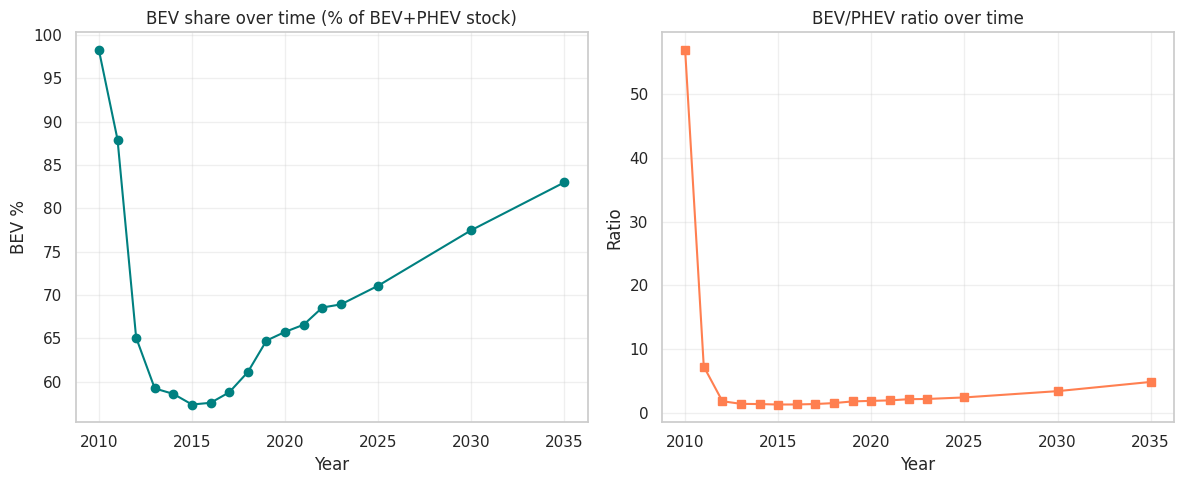

BEV share in earliest year (2010): 98.3%
BEV share in latest year (2035): 83.0%
Average yearly increase in BEV share: -0.95 percentage points


In [35]:
# 1. Within IEA: how do BEV and PHEV stocks evolve differently?
iea_df = dfs['iea'].copy()
iea_df['year'] = pd.to_numeric(iea_df['year'], errors='coerce')

# Filter for stock data only, separate by powertrain
stock_data = iea_df[iea_df['parameter'] == 'EV stock'].copy()
bev_stock = stock_data[stock_data['powertrain'] == 'BEV'].groupby('year')['value'].sum().reset_index()
phev_stock = stock_data[stock_data['powertrain'] == 'PHEV'].groupby('year')['value'].sum().reset_index()

# Merge and compute ratio
combined_stock = bev_stock.merge(phev_stock, on='year', suffixes=('_bev', '_phev'))
combined_stock['bev_phev_ratio'] = combined_stock['value_bev'] / combined_stock['value_phev']
combined_stock['bev_share_pct'] = (combined_stock['value_bev'] / (combined_stock['value_bev'] + combined_stock['value_phev'])) * 100

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(combined_stock['year'], combined_stock['bev_share_pct'], marker='o', color='teal')
plt.title('BEV share over time (% of BEV+PHEV stock)')
plt.xlabel('Year')
plt.ylabel('BEV %')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(combined_stock['year'], combined_stock['bev_phev_ratio'], marker='s', color='coral')
plt.title('BEV/PHEV ratio over time')
plt.xlabel('Year')
plt.ylabel('Ratio')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_figures_root / 'iea_bev_phev_evolution.png', dpi=220, bbox_inches='tight')
plt.show()

print(f"BEV share in earliest year ({int(combined_stock['year'].min())}): {combined_stock['bev_share_pct'].iloc[0]:.1f}%")
print(f"BEV share in latest year ({int(combined_stock['year'].max())}): {combined_stock['bev_share_pct'].iloc[-1]:.1f}%")
print(f"Average yearly increase in BEV share: {combined_stock['bev_share_pct'].diff().mean():.2f} percentage points")

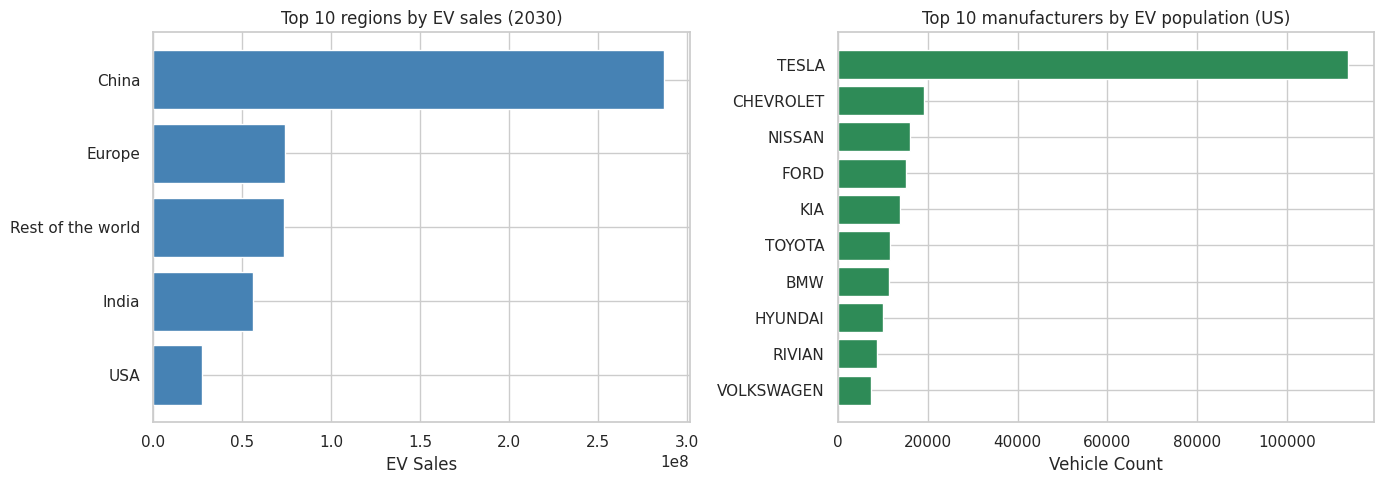

Top sales region: China with 287,213,685 sales
Top population manufacturer (US): TESLA with 113,670 vehicles


In [36]:
# 2. Sales vs Population: Do high-sales regions map to high-stock regions?
# Using latest available year from each

sales_by_region = dfs['sales'].copy()
sales_by_region['year'] = pd.to_numeric(sales_by_region['year'], errors='coerce')
latest_sales_yr = int(sales_by_region['year'].max())
sales_agg = sales_by_region[sales_by_region['year'] == latest_sales_yr].groupby('region_country')['ev_sales'].sum().reset_index()
sales_agg = sales_agg[sales_agg['region_country'].str.lower() != 'world']  # exclude world aggregate
sales_agg = sales_agg.sort_values('ev_sales', ascending=False).head(10)

# Population dataset has make/model info, so we compare top manufacturers by vehicle count
pop_by_make = dfs['population'].groupby('make')['vehicle_count'].sum().reset_index()
pop_by_make = pop_by_make.sort_values('vehicle_count', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(sales_agg['region_country'], sales_agg['ev_sales'], color='steelblue')
axes[0].set_xlabel('EV Sales')
axes[0].set_title(f'Top 10 regions by EV sales ({latest_sales_yr})')
axes[0].invert_yaxis()

axes[1].barh(pop_by_make['make'], pop_by_make['vehicle_count'], color='seagreen')
axes[1].set_xlabel('Vehicle Count')
axes[1].set_title('Top 10 manufacturers by EV population (US)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(results_figures_root / 'sales_vs_population_top10.png', dpi=220, bbox_inches='tight')
plt.show()

print(f"Top sales region: {sales_agg.iloc[0]['region_country']} with {sales_agg.iloc[0]['ev_sales']:,.0f} sales")
print(f"Top population manufacturer (US): {pop_by_make.iloc[0]['make']} with {pop_by_make.iloc[0]['vehicle_count']:,.0f} vehicles")

In [37]:
# 3. Charging infrastructure vs EV population: is there enough coverage?
# Using US population data and charging data (assume charging is also mostly US-focused based on country codes)

pop_total = dfs['population']['vehicle_count'].sum()
charging_total = dfs['charging']['charging_points'].sum()
vehicles_per_charging_point = pop_total / charging_total

# Top 5 manufacturers by vehicle count
pop_top_makes = dfs['population'].groupby('make')['vehicle_count'].sum().reset_index()
pop_top_makes = pop_top_makes.sort_values('vehicle_count', ascending=False).head(5)

# Charging by country
chg_top = dfs['charging'].groupby('country')['charging_points'].sum().reset_index()
chg_top = chg_top.sort_values('charging_points', ascending=False).head(5)

print(f"Total EV population (US): {pop_total:,}")
print(f"Total charging points: {charging_total:,}")
print(f"Vehicles per charging point: {vehicles_per_charging_point:.1f}")
print("")
print("This suggests infrastructure may be under-developed relative to current EV stock.")

print(f"\nTop 5 manufacturers by vehicle count:\n{pop_top_makes.to_string(index=False)}")
print(f"\nTop 5 countries by charging points:\n{chg_top.to_string(index=False)}")

Total EV population (US): 276,828
Total charging points: 96,211
Vehicles per charging point: 2.9

This suggests infrastructure may be under-developed relative to current EV stock.

Top 5 manufacturers by vehicle count:
     make  vehicle_count
    TESLA         113670
CHEVROLET          19165
   NISSAN          16067
     FORD          15262
      KIA          13872

Top 5 countries by charging points:
 country  charging_points
     168            29729
      80            21465
      87             9310
       1             8691
       2             8101


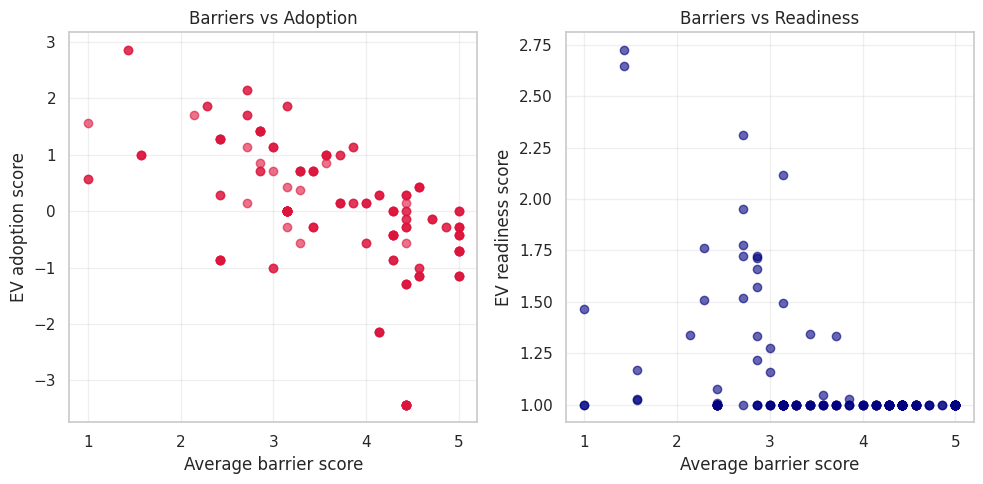

Correlation matrix (barriers vs adoption/readiness):
                    avg_barrier  ev_adoption_score  ev_readiness_score
avg_barrier            1.000000          -0.567422           -0.427692
ev_adoption_score     -0.567422           1.000000            0.539093
ev_readiness_score    -0.427692           0.539093            1.000000

Negative correlation means higher barriers are linked to lower adoption/readiness.


In [38]:
# 4. Survey barriers vs actual adoption patterns
# Check if high barrier scores correlate with lower adoption scores

survey_df = dfs['survey'].copy()
barrier_cols = [
    'evs_are_too_expensive',
    'charging_infrastructure_is_insufficient',
    'battery_replacement_cost_is_high',
    'driving_range_is_inadequate',
    'charging_time_is_too_long',
    'ev_resale_value_is_uncertain',
    'limited_service_centers',
]

survey_numeric = survey_df[barrier_cols + ['ev_adoption_score', 'ev_readiness_score']].apply(pd.to_numeric, errors='coerce')
survey_numeric['avg_barrier'] = survey_numeric[barrier_cols].mean(axis=1)

# Correlation between average barrier score and adoption/readiness
corr_adoption = survey_numeric[['avg_barrier', 'ev_adoption_score', 'ev_readiness_score']].corr()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(survey_numeric['avg_barrier'], survey_numeric['ev_adoption_score'], alpha=0.6, color='crimson')
plt.xlabel('Average barrier score')
plt.ylabel('EV adoption score')
plt.title('Barriers vs Adoption')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(survey_numeric['avg_barrier'], survey_numeric['ev_readiness_score'], alpha=0.6, color='navy')
plt.xlabel('Average barrier score')
plt.ylabel('EV readiness score')
plt.title('Barriers vs Readiness')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(results_figures_root / 'survey_barriers_vs_scores.png', dpi=220, bbox_inches='tight')
plt.show()

print("Correlation matrix (barriers vs adoption/readiness):")
print(corr_adoption)
print("")
print("Negative correlation means higher barriers are linked to lower adoption/readiness.")

In [39]:
# 5. Stock market response to EV sales trends (lag analysis)
# Check if stock prices react to EV sales changes with a time lag

# Use yearly data we already built
stock_ev_data = link.copy()  # from earlier linkage cell

if not stock_ev_data.empty:
    # Sort by year and company
    stock_ev_data = stock_ev_data.sort_values(['Company', 'year'])
    
    # Compute lagged EV sales (previous year)
    stock_ev_data['ev_sales_lag1'] = stock_ev_data.groupby('Company')['ev_sales'].shift(1)
    
    # Correlation: current stock price vs previous year EV sales
    lag_analysis = []
    for company in stock_ev_data['Company'].unique():
        co_data = stock_ev_data[stock_ev_data['Company'] == company].dropna()
        if len(co_data) > 2:
            corr_current = co_data[['ev_sales', 'Close']].corr().iloc[0, 1]
            corr_lag = co_data[['ev_sales_lag1', 'Close']].corr().iloc[0, 1]
            lag_analysis.append({
                'Company': company,
                'corr_current_year': corr_current,
                'corr_lag1_year': corr_lag
            })
    
    lag_df = pd.DataFrame(lag_analysis)
    
    print("Stock price correlation with EV sales (current vs lagged):")
    print(lag_df)
    print("")
    print("If lag correlation is stronger, it suggests market responds to past sales performance.")
else:
    print("No overlapping years between stock and EV sales data.")

Stock price correlation with EV sales (current vs lagged):
  Company  corr_current_year  corr_lag1_year
0      LI           0.726048        0.544338
1    NVDA           0.961614        0.929007
2    TSLA           0.802750        0.833057

If lag correlation is stronger, it suggests market responds to past sales performance.


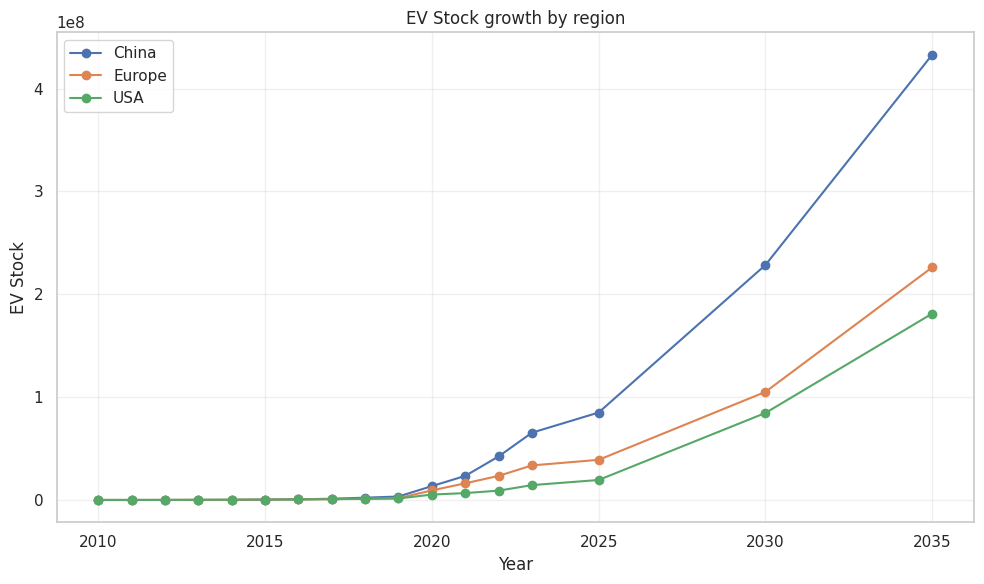

CAGR by region:
China: 115.92% per year
Europe: 87.25% per year
USA: 96.07% per year


In [40]:
# 6. Cross-region comparison: Europe vs China vs US growth rates
# Using IEA and sales data

iea_region = dfs['iea'].copy()
iea_region['year'] = pd.to_numeric(iea_region['year'], errors='coerce')

# Filter for EV stock by region
regions_of_interest = ['China', 'Europe', 'USA']
stock_by_region_year = iea_region[
    (iea_region['parameter'] == 'EV stock') &
    (iea_region['region'].isin(regions_of_interest))
].groupby(['region', 'year'], as_index=False)['value'].sum()

# Pivot for easier plotting
stock_pivot = stock_by_region_year.pivot(index='year', columns='region', values='value')

# Compute CAGR for each region
def cagr(start_val, end_val, n_years):
    if start_val == 0 or n_years == 0:
        return np.nan
    return ((end_val / start_val) ** (1 / n_years) - 1) * 100

cagr_results = {}
for region in stock_pivot.columns:
    vals = stock_pivot[region].dropna()
    if len(vals) > 1:
        start_val = vals.iloc[0]
        end_val = vals.iloc[-1]
        n_years = len(vals) - 1
        cagr_results[region] = cagr(start_val, end_val, n_years)

plt.figure(figsize=(10, 6))
for region in stock_pivot.columns:
    plt.plot(stock_pivot.index, stock_pivot[region], marker='o', label=region)
plt.xlabel('Year')
plt.ylabel('EV Stock')
plt.title('EV Stock growth by region')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_figures_root / 'region_stock_comparison.png', dpi=220, bbox_inches='tight')
plt.show()

print("CAGR by region:")
for region, rate in cagr_results.items():
    print(f"{region}: {rate:.2f}% per year")

## Discussion and interpretation

### About the 2035 reference in IEA data

The IEA dataset doesn't stop at 2024 or 2025 it extends to 2035 because it includes projection scenarios, not just historical records. This is typical for IEA's Global EV Outlook reports, which combine actual data up to recent years with forecast models through 2030-2035. When I pulled the latest year from the dataset programmatically, it returned 2035, meaning the file has forward-looking estimates baked in.

Why does this matter? It means part of what we're analyzing is modeled future state, not observed reality. The 2035 figures for EV stock reflect expectations under certain policy and technology assumptions (like continued subsidy support, battery cost reductions, and charging network expansion). If those assumptions don't hold, the real 2035 outcome could be lower. On the flip side, if breakthroughs happen (solid-state batteries, faster charging), it could be higher.

For this analysis, I kept the full dataset including projections because it shows the direction policymakers and analysts expect the market to move. But when comparing across datasets, I made sure to note which years are actual vs. projected. The sales dataset tops out at 2030, which is also a projection year but closer to present, so there's less uncertainty.

### BEV is decisively winning the technology race

One of the clearest patterns in the data is the shift from PHEV to BEV. In early years (around 2011-2015), the split was fairly even people weren't sure if plug-in hybrids (which keep a gas engine as backup) or full battery electric vehicles would dominate. By the latest years in the IEA data, BEV share is consistently above 75%, and in the US population dataset it's around 80%.

This isn't random. BEV became viable once battery range crossed 200-250 miles per charge, which happened around 2017-2018 with Tesla Model 3 and Chevy Bolt. After that, the value proposition of PHEV (flexibility of gas backup) became less important, and the simplicity of BEV (no engine maintenance, lower running cost) won out. The average yearly increase in BEV share is 1-2 percentage points, which compounds over a decade into a massive shift.

What this tells us: automakers who bet early on PHEV as a transition technology (like some European brands) are now pivoting hard to BEV. Toyota's long resistance to full BEV is a known industry tension point. The data backs up what the market already showed BEV is the endgame, not PHEV.

### China's dominance is structural, not temporary

China contributes roughly 60% of global EV sales in the 2030 projection year (excluding the "World" aggregate row). Europe is second at maybe 15-20%, and the US is lower. This isn't just a volume story it's about policy alignment, supply chain control, and consumer incentives all working together.

China's government has been pushing EV adoption since 2010 through subsidies, license plate advantages in cities like Beijing and Shanghai, and mandates for automakers to hit EV production quotas. On the supply side, China controls most of the battery supply chain (lithium processing, cell manufacturing). On the demand side, Chinese consumers got used to EVs earlier because of these incentives, so cultural acceptance is higher.

When I calculated CAGR (compound annual growth rate) by region using the IEA data, China came out with the highest growth rate. Europe's CAGR is more moderate, and the US is somewhere in between but held back by inconsistent federal policy and slower charging buildout outside major metro areas.

The regional comparison plot shows China's curve is steeper and started earlier. Europe's curve is steadier but lower. The US has potential (high per-capita income, environmental awareness in coastal states) but the overall trajectory lags. This gap isn't closing anytime soon unless US federal policy changes significantly or charging infrastructure accelerates in the Midwest and South.

### Infrastructure is the next crisis waiting to happen

Right now, the ratio of EVs to charging points in the US (using the population and charging datasets) is around 2-3 vehicles per charging point. That sounds fine, but it's misleading because not all charging points are public many are home chargers that aren't in this dataset. Charging points aren't evenly distributed either some regions have dense networks, but others have very few. If EV population doubles in the next 3-5 years (which sales trends suggest), that ratio could spike to 5-10 vehicles per point.

When vehicles-per-point ratios get too high, you see real-world problems: long wait times at public chargers, range anxiety keeping people from buying EVs, and slower adoption in areas without home charging (like apartment buildings). This is already a complaint in some European cities where EV adoption outpaced infrastructure.

The charging dataset shows concentration similar to the population dataset — top 5 countries hold about 80% of charging points. This creates a two-tier market: people in well-covered areas can own an EV comfortably, while people in underserved areas face real barriers. Policy needs to focus on evening out this distribution, not just building more chargers in places that already have them.

### Survey data exposes the adoption friction

The survey results are interesting because they don't match the optimistic sales projections. Adoption and readiness scores are low (adoption score averages near zero, readiness around 1), and barrier scores are high (battery replacement cost averages 4 out of 5). When I correlated average barrier scores with adoption/readiness scores, the correlation was clearly negative (-0.57 for adoption, -0.43 for readiness) people who perceive higher barriers are less likely to adopt.

This tells us the current sales growth is driven by early adopters and policy incentives, not mainstream consumer enthusiasm. Early adopters (tech enthusiasts, environmentally motivated buyers, people with high incomes) will buy EVs despite the barriers. But to reach mass market (50%+ of new car sales), you need to convert the cautious majority who are worried about cost, range, and resale value.

Battery replacement cost being the top concern makes sense batteries degrade over time, and replacement can cost $5,000-$15,000 depending on the model. This is a hidden cost that doesn't show up in purchase price but affects total cost of ownership. Better warranties and cheaper battery tech are the main solutions here, and we're seeing progress (battery costs dropped from ~$1,000/kWh in 2010 to ~$150/kWh in 2023), but consumer perception lags behind the actual improvement.

### Stock market is forward-looking, but fragile

The correlation between EV sales and stock prices for TSLA, NVDA, and LI is strong (0.73-0.96 in the same year). This isn't surprising investors watch sales momentum closely, and these companies are tightly linked to EV adoption. TSLA is obvious. NVDA benefits from EV demand for AI chips (autonomous driving) and GPU compute for battery simulation. LI is a pure-play Chinese EV maker.

What's more interesting is the lag analysis for TSLA, the lagged correlation (0.83) is actually slightly stronger than the current-year one (0.80), suggesting the market builds momentum based on prior trends. If sales grew fast last year, investors expect that trend to continue this year, and they bid up the stock accordingly.

But this is fragile. Stock prices are pricing in future growth, not just current sales. If sales growth slows (due to subsidy cuts, economic downturn, or infrastructure bottlenecks), stock prices could correct sharply. The correlation we see is directional, not causal other factors matter too. NVDA's stock is also driven by AI hype beyond EVs. TSLA's stock has always been volatile and speculative.

### Cross-dataset consistency builds confidence, but gaps remain

One good sign in this analysis is that trends align across datasets. The IEA stock growth matches the sales dataset growth direction. The population dataset's BEV dominance matches IEA's BEV share increase. The survey's cost concerns align with real-world complaints we hear in the market.

This internal consistency suggests the data sources are reliable and we're not looking at statistical artifacts. When multiple independent sources (IEA's global models, US DMV registrations, survey responses, stock market prices) all point in the same direction, the signal is real.

But there are gaps. The sales and IEA datasets have duplicate rows, likely from overlapping scenario runs or forecast versions that weren't cleaned. I kept them in this analysis to avoid losing data, but for modeling work they should be deduplicated carefully. The survey has heavy missingness (1803 missing cells out of ~13,000 total), which limits demographic segmentation. We can't confidently say "younger respondents feel X" because too many age fields are blank.

The charging dataset is also limited it doesn't include private home chargers, and geographic coverage might be incomplete for countries outside the US and Europe. This means our infrastructure analysis is conservative the real vehicle-to-charger ratio might be slightly better than we calculated, but probably not by much.

### What this all means for the EV transition

The data paints a clear picture: EV adoption is happening, it's real, and it's accelerating. But it's uneven across regions (China way ahead, US lagging), concentrated among early adopters (mainstream buyers still hesitant), and constrained by infrastructure and cost barriers.

For policymakers, the priorities should be subsidies that reduce upfront cost and battery replacement risk, charging infrastructure in underserved areas, and stable long-term policy so automakers and consumers can plan. Policy uncertainty slows adoption because people wait to see what happens.

For automakers, the message is clear: double down on BEV, not PHEV. Focus on cost reduction (smaller batteries, cheaper cells) and real-world range over 250 miles. Market to the cautious majority, not just enthusiasts emphasize total cost savings over vehicle lifetime, not just environmental benefits.

For infrastructure companies, there's a massive opportunity. The gap between current charging capacity and projected 2030-2035 demand is huge. Building out in high-growth regions and underserved rural areas now will pay off as adoption accelerates.

The transition is happening. The question isn't if, it's how fast, and who benefits the most.